In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eco-driving-behavior-dataset/eco_driving_score.csv


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv('/kaggle/input/eco-driving-behavior-dataset/eco_driving_score.csv')

In [4]:
df.head(5)

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
0,2147,5,14.2,7.87,0.97,42.1
1,1703,3,4.2,9.37,0.50,36.1
2,2253,0,5.5,8.85,0.78,49.8
3,2866,3,21.7,5.87,0.60,27.7
4,1636,2,3.1,6.71,0.99,79.4


In [5]:
df.isnull().sum()

rpm_variation              0
harsh_braking_count        0
idling_time                0
fuel_consumption           0
acceleration_smoothness    0
eco_score                  0
dtype: int64

In [6]:
df.columns

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')

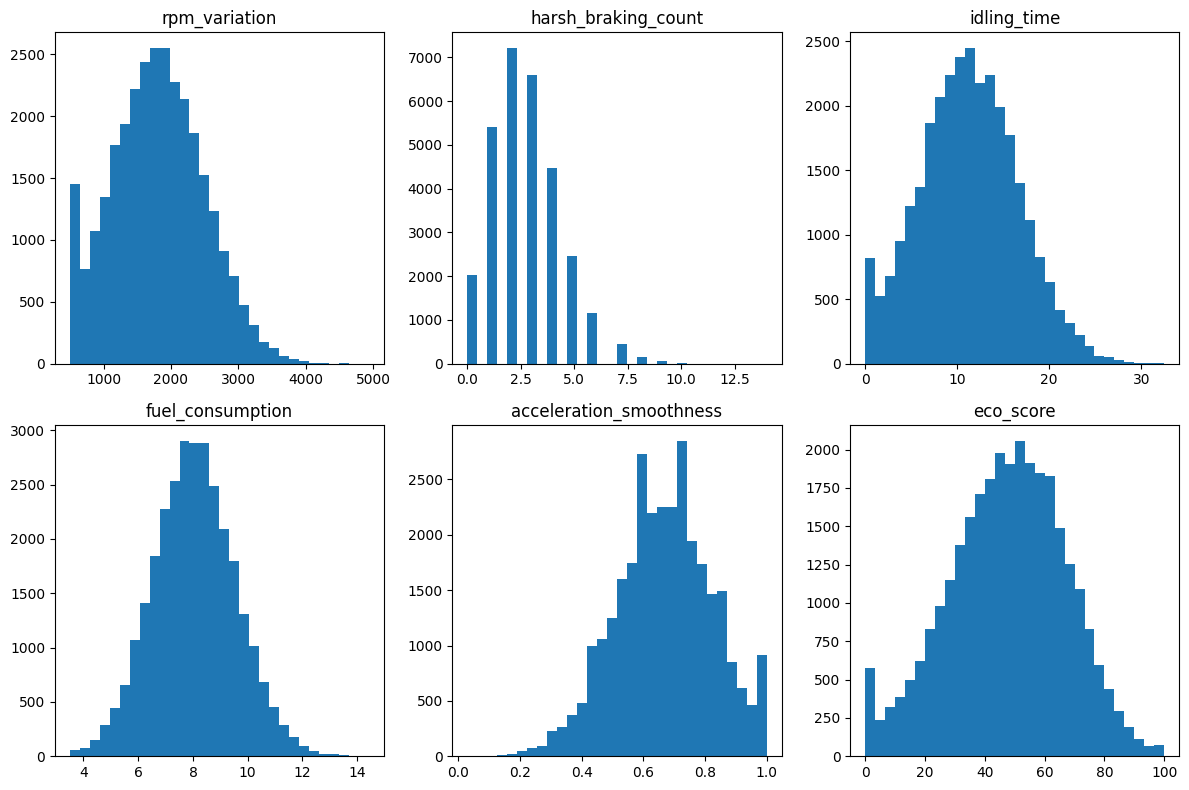

In [7]:
cols = [
    'rpm_variation', 'harsh_braking_count', 'idling_time',
    'fuel_consumption', 'acceleration_smoothness', 'eco_score'
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

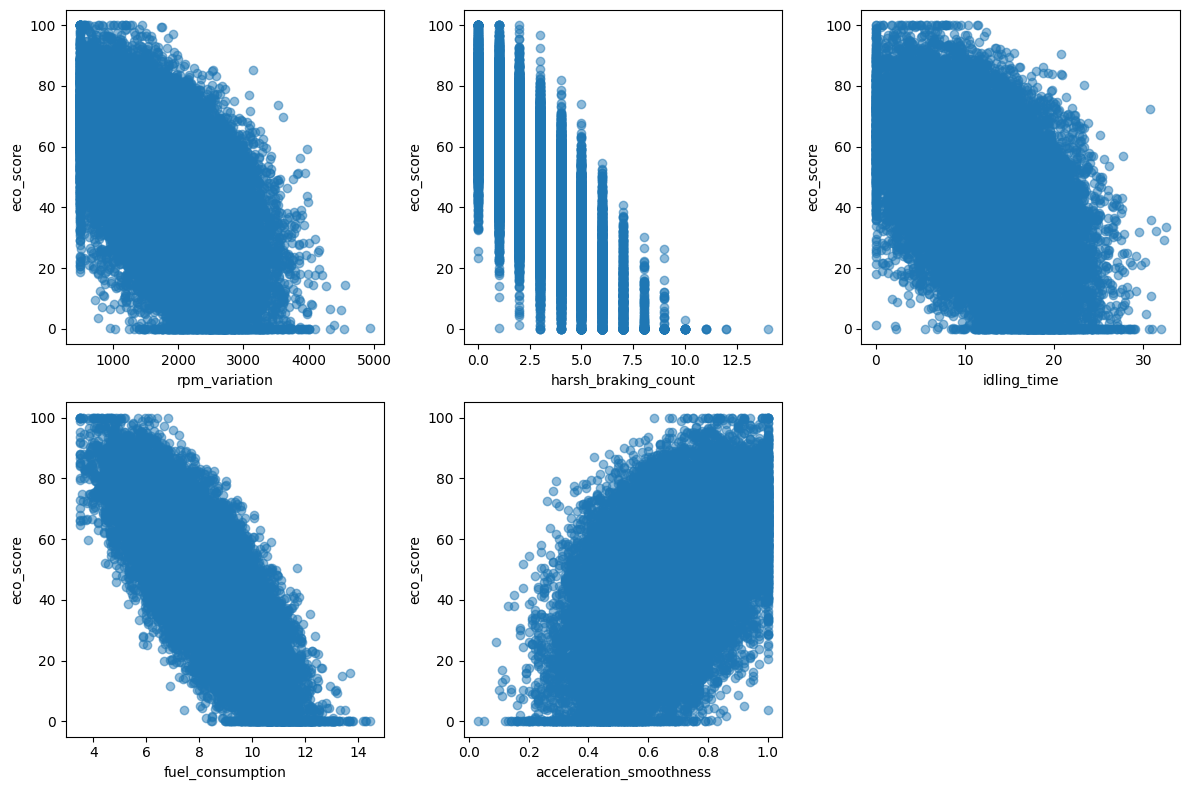

In [8]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(cols[:-1], 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[col], df['eco_score'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('eco_score')
plt.tight_layout()
plt.show()

In [9]:
corre = df.corr()

In [10]:
corre['eco_score']

rpm_variation             -0.537513
harsh_braking_count       -0.742530
idling_time               -0.468010
fuel_consumption          -0.770575
acceleration_smoothness    0.481003
eco_score                  1.000000
Name: eco_score, dtype: float64

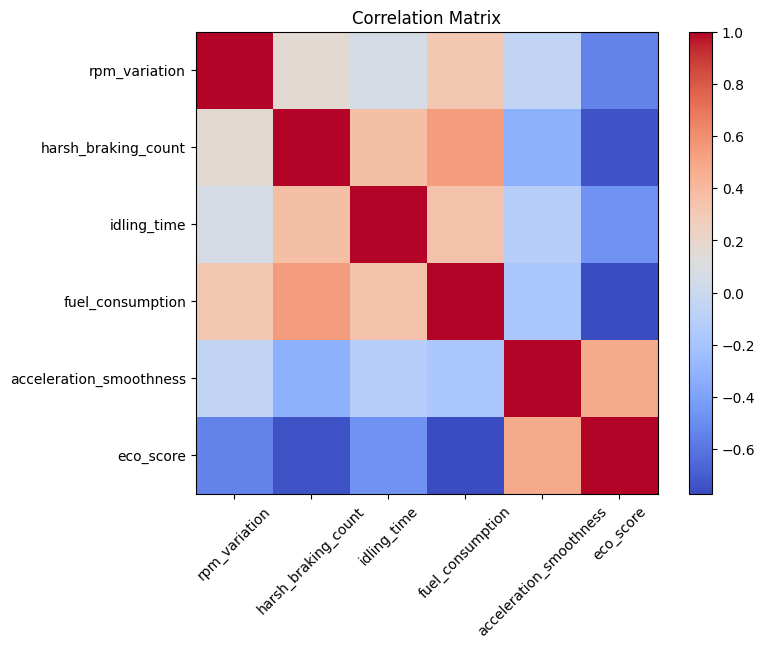

In [11]:
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title('Correlation Matrix')
plt.show()

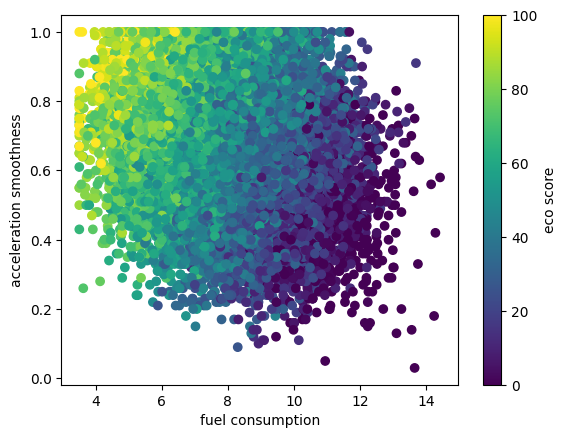

In [12]:
plt.scatter(
    df['fuel_consumption'],
    df['acceleration_smoothness'],
    c = df['eco_score']
)
plt.xlabel('fuel consumption')
plt.ylabel('acceleration smoothness')
plt.colorbar(label = 'eco score')
plt.show()

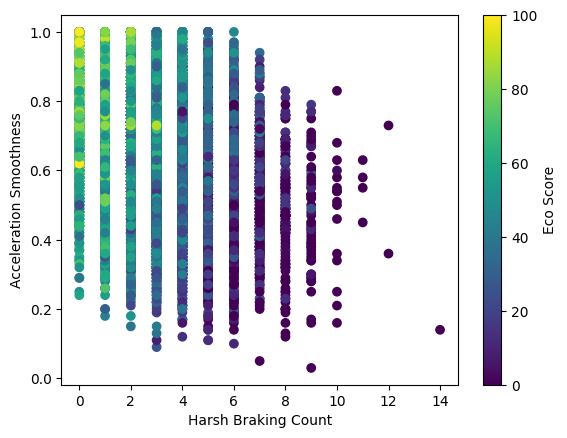

In [13]:
plt.scatter(
    df['harsh_braking_count'],
    df['acceleration_smoothness'],
    c=df['eco_score']
)
plt.xlabel('Harsh Braking Count')
plt.ylabel('Acceleration Smoothness')
plt.colorbar(label='Eco Score')
plt.show()

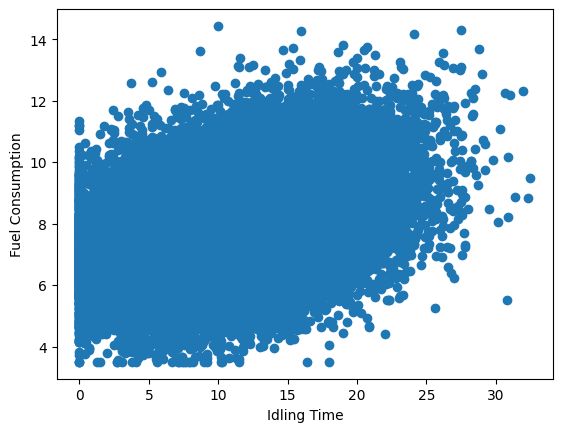

In [14]:
plt.scatter(df['idling_time'], df['fuel_consumption'])
plt.xlabel('Idling Time')
plt.ylabel('Fuel Consumption')
plt.show()

/tmp/ipykernel_17/1148866366.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(bins)['eco_score'].mean()


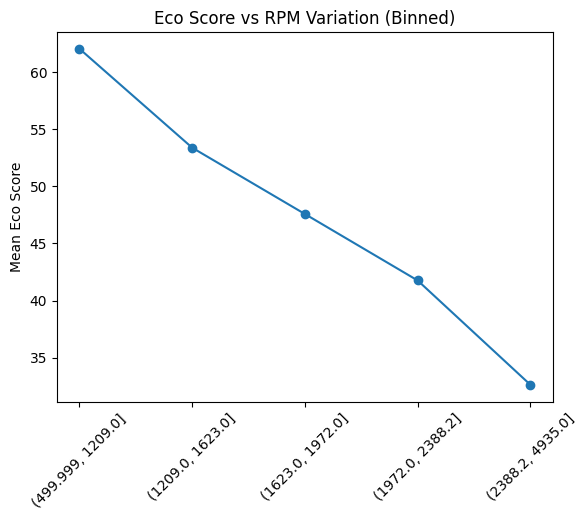

In [15]:
bins = pd.qcut(df['rpm_variation'], 5)
grouped = df.groupby(bins)['eco_score'].mean()

plt.plot(grouped.values, marker='o')
plt.xticks(range(5), grouped.index.astype(str), rotation=45)
plt.ylabel('Mean Eco Score')
plt.title('Eco Score vs RPM Variation (Binned)')
plt.show()

/tmp/ipykernel_17/2302551539.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in cols], labels=cols)


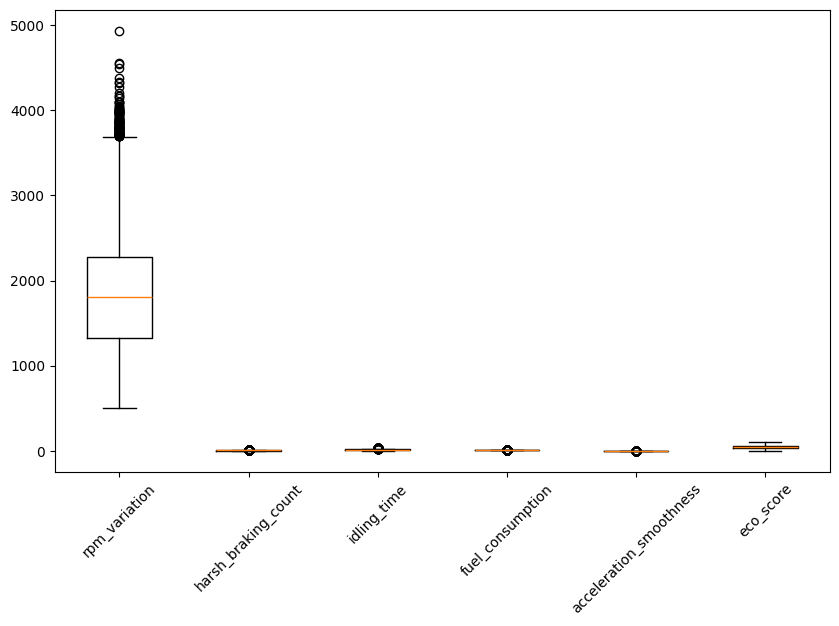

In [16]:
plt.figure(figsize=(10, 6))
plt.boxplot([df[c] for c in cols], labels=cols)
plt.xticks(rotation=45)
plt.show()

In [17]:
X = df.drop('eco_score',axis = 1 )
y= df['eco_score']

In [18]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [19]:
from sklearn.svm import SVR
from sklearn.svm import LinearSVR

In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr' , LinearSVR())
])

In [21]:
from sklearn.model_selection import cross_validate
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

res = cross_validate(pipeline , X_train, y_train,cv = 5 , scoring = scoring)


In [22]:
res

{'fit_time': array([0.04231715, 0.03372192, 0.03567743, 0.0369513 , 0.03394961]),
 'score_time': array([0.00489306, 0.00469303, 0.00503016, 0.00471067, 0.00496674]),
 'test_MAE': array([-4.10632383, -4.01162083, -4.04137886, -3.93286296, -4.05471193]),
 'test_RMSE': array([-5.25002759, -5.03490193, -5.14073152, -5.01504912, -5.1635539 ]),
 'test_R2': array([0.92741431, 0.9338652 , 0.93184514, 0.93381205, 0.92964722])}

In [23]:
res

{'fit_time': array([0.04231715, 0.03372192, 0.03567743, 0.0369513 , 0.03394961]),
 'score_time': array([0.00489306, 0.00469303, 0.00503016, 0.00471067, 0.00496674]),
 'test_MAE': array([-4.10632383, -4.01162083, -4.04137886, -3.93286296, -4.05471193]),
 'test_RMSE': array([-5.25002759, -5.03490193, -5.14073152, -5.01504912, -5.1635539 ]),
 'test_R2': array([0.92741431, 0.9338652 , 0.93184514, 0.93381205, 0.92964722])}

In [24]:
param_dist = {
    'svr__C': np.logspace(-3, 3, 50),      # 0.001 → 1000
    'svr__epsilon': np.linspace(0.01, 1.0, 50),
    'svr__loss': ['epsilon_insensitive', 'squared_epsilon_insensitive']
}

In [25]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions= param_dist,
    n_iter = 40,
    scoring = 'neg_root_mean_squared_error',
    cv = 5,
    verbose = 2,
    n_jobs = -1 
)

In [26]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

[CV] END svr__C=0.06866488450043001, svr__epsilon=0.11102040816326529, svr__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END svr__C=0.06866488450043001, svr__epsilon=0.11102040816326529, svr__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END svr__C=0.03906939937054617, svr__epsilon=0.5959183673469388, svr__loss=epsilon_insensitive; total time=   0.0s
[CV] END svr__C=0.03906939937054617, svr__epsilon=0.5959183673469388, svr__loss=epsilon_insensitive; total time=   0.0s
[CV] END svr__C=1000.0, svr__epsilon=0.676734693877551, svr__loss=epsilon_insensitive; total time=   2.7s
[CV] END svr__C=0.1206792640639329, svr__epsilon=0.2120408163265306, svr__loss=epsilon_insensitive; total time=   0.0s
[CV] END svr__C=0.1206792640639329, svr__epsilon=0.2120408163265306, svr__loss=epsilon_insensitive; total time=   0.0s
[CV] END svr__C=6.25055192527397, svr__epsilon=0.7777551020408163, svr__loss=epsilon_insensitive; total time=   0.4s
[CV] END svr__C=6.25055192527397, svr__ep

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('svr', LinearSVR())]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'svr__C': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-0...
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ]),
                                        'svr__loss': ['epsilon_insensitive',
                                                      'squared_epsilon_insensitive']},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [27]:
print('best cv RMSE ', random_search.best_score_)
print('best parameter', random_search.best_params_)

best cv RMSE  -5.116429480960255
best parameter {'svr__loss': 'squared_epsilon_insensitive', 'svr__epsilon': np.float64(0.13122448979591836), 'svr__C': np.float64(568.9866029018293)}


In [28]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R2:", r2)

Test RMSE: 5.018700581745687
Test R2: 0.9321610978459558
